In [1]:
import pandas as pd

df_load = pd.read_csv("../data/Load_2022_clean.csv")
df_pv = pd.read_csv("../data/PV_2022_clean.csv")
df_weather = pd.read_csv("../data/Weather_clean_NEMS.csv")

In [2]:
df_load.head()

,TimestampInUtc,House1,House2,House3,Sum
0,2021-12-31 23:00,4.687989,13.361136,3.210137,21.259262
1,2021-12-31 23:15,5.775093,10.841218,3.185691,19.802003
2,2021-12-31 23:30,5.579068,4.176180,3.106543,12.861791
3,2021-12-31 23:45,6.073584,4.377591,11.027538,21.478712
4,2022-01-01 00:00,10.755348,6.999270,9.518171,27.272789


In [3]:
df_pv.head()

,TimestampInUtc,PV
0,2021-12-31 23:00,0.0
1,2021-12-31 23:15,0.0
2,2021-12-31 23:30,0.0
3,2021-12-31 23:45,0.0
4,2022-01-01 00:00,0.0


In [4]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [5]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
print(df_weather.columns)
print(df_weather.index.name)


Index(['timestamp', 'Temperature', 'Sunshine Duration', 'Shortwave Radiation',
       'Direct Shortwave Radiation', 'Diffuse Shortwave Radiation',
       'Snowfall Amount', 'Relative Humidity', 'Cloud Cover Total'],
      dtype='object')
None


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ensure datetime index
df_load = df_load.copy()

if "TimestampInUtc" in df_load.columns:
    df_load["TimestampInUtc"] = pd.to_datetime(df_load["TimestampInUtc"], errors="coerce")
    df_load = df_load.dropna(subset=["TimestampInUtc"])
    df_load = df_load.set_index("TimestampInUtc")
else:
    if not isinstance(df_load.index, pd.DatetimeIndex):
        df_load.index = pd.to_datetime(df_load.index, errors="coerce")
        df_load = df_load.loc[df_load.index.notna()]


In [8]:
nan_count = df_load.isna().sum()
nan_pct = (df_load.isna().mean() * 100).round(2)

nan_summary = (
    pd.DataFrame({"nan_count": nan_count, "nan_pct": nan_pct})
    .sort_values("nan_count", ascending=False)
)

nan_summary


,nan_count,nan_pct
House1,3,0.01
House2,3,0.01
House3,3,0.01
Sum,3,0.01


In [9]:
df_load_filled = df_load.copy()

numeric_cols = df_load_filled.select_dtypes(include="number").columns

df_load_filled[numeric_cols] = df_load_filled[numeric_cols].interpolate(
    method="time",
    limit_direction="both"
)

# Optional: if you want to be strict and still forward-fill any remaining edge cases
df_load_filled[numeric_cols] = df_load_filled[numeric_cols].ffill().bfill()

# check remaining NaNs
df_load_filled.isna().sum().sort_values(ascending=False)


House1    0
House2    0
House3    0
Sum       0
dtype: int64

In [10]:
#Recompute sum
house_cols = [c for c in ["House1", "House2", "House3"] if c in df_load_filled.columns]

if len(house_cols) > 0:
    df_load_filled["Sum"] = df_load_filled[house_cols].sum(axis=1)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def ensure_datetime_index(df: pd.DataFrame, candidates: list[str]) -> pd.DataFrame:
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex):
        return df

    time_col = None
    for c in candidates:
        if c in df.columns:
            time_col = c
            break

    if time_col is None:
        first_col = df.columns[0]
        time_col = first_col

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col])
    df = df.set_index(time_col)
    return df

# --- ensure datetime index for each ---
df_weather = ensure_datetime_index(df_weather, ["timestamp", "Timestamp", "time", "date", "Date"])
df_pv      = ensure_datetime_index(df_pv,      ["TimestampInUtc", "timestamp", "Timestamp"])
df_load    = ensure_datetime_index(df_load,    ["TimestampInUtc", "timestamp", "Timestamp"])

# --- resample to hourly ---
df_pv_hour = df_pv.resample("h").mean()
df_load_hour = df_load.resample("h").mean()

# --- merge ---
df = df_weather.join(df_pv_hour, how="inner").join(df_load_hour, how="inner")

df.head()


,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,PV,House1,House2,House3,Sum
2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,12.010945,7.677682,7.828829,27.517455
2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,6.624415,12.098659,15.910827,34.633901
2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,0.0,12.303576,8.109732,17.125447,37.538755
2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,0.0,15.779807,7.291059,3.225149,26.296015
2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,12.096437,8.520094,2.655528,23.272059


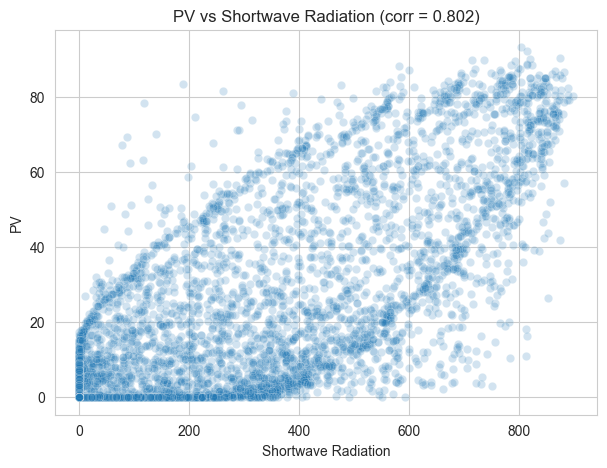

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["Shortwave Radiation"]
y = df["PV"]

# compute correlation
corr = x.corr(y)

plt.figure(figsize=(7,5))
sns.scatterplot(x=x, y=y, alpha=0.2)

plt.title(f"PV vs Shortwave Radiation (corr = {corr:.3f})")
plt.xlabel("Shortwave Radiation")
plt.ylabel("PV")

plt.show()


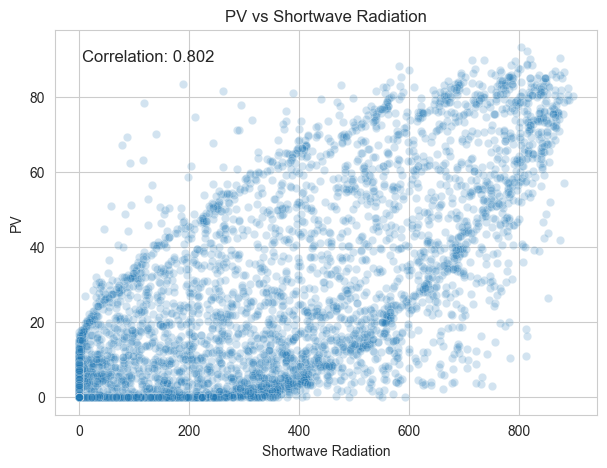

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=x, y=y, alpha=0.2)

plt.text(
    0.05, 0.95,
    f"Correlation: {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.title("PV vs Shortwave Radiation")
plt.show()


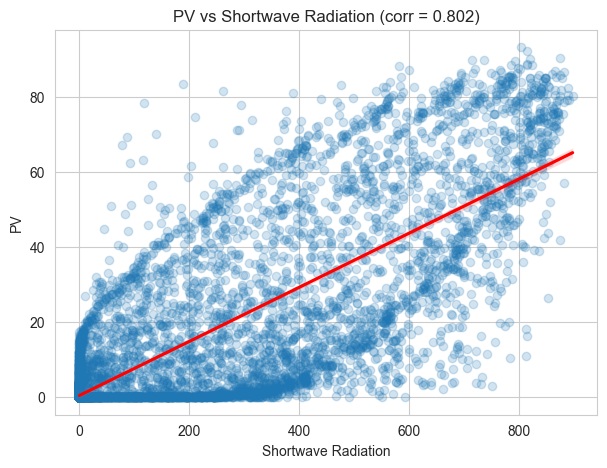

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

x1 = df["Shortwave Radiation"]
y = df["PV"]

corr1 = x1.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x1,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"PV vs Shortwave Radiation (corr = {corr1:.3f})")
plt.xlabel("Shortwave Radiation")
plt.ylabel("PV")
plt.show()


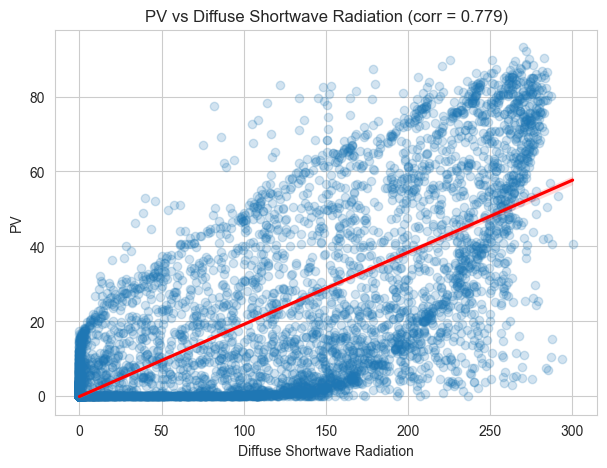

In [15]:
x2 = df["Diffuse Shortwave Radiation"]
corr2 = x2.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x2,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"PV vs Diffuse Shortwave Radiation (corr = {corr2:.3f})")
plt.xlabel("Diffuse Shortwave Radiation")
plt.ylabel("PV")
plt.show()


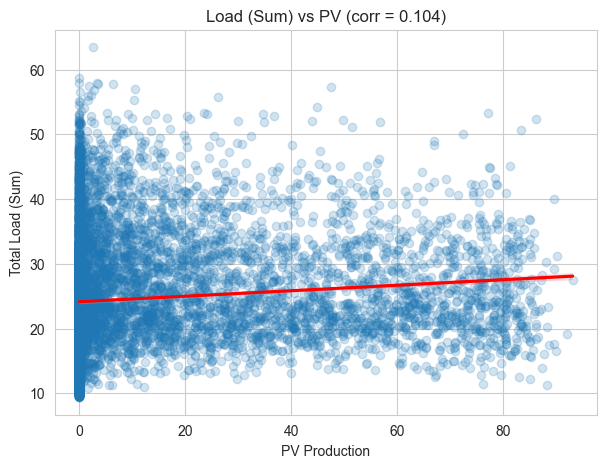

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["PV"]
y = df["Sum"]

corr = x.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"Load (Sum) vs PV (corr = {corr:.3f})")
plt.xlabel("PV Production")
plt.ylabel("Total Load (Sum)")
plt.show()


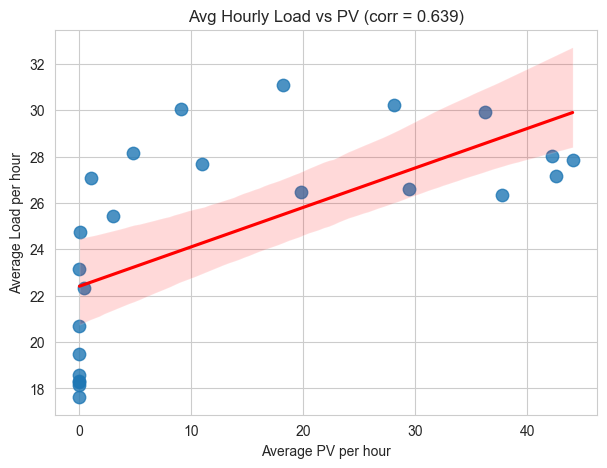

In [17]:
df["hour"] = df.index.hour
hourly = df.groupby("hour")[["PV","Sum"]].mean()

corr_hourly = hourly["PV"].corr(hourly["Sum"])

plt.figure(figsize=(7,5))
sns.regplot(
    x=hourly["PV"],
    y=hourly["Sum"],
    scatter_kws={"s":80},
    line_kws={"color":"red"}
)

plt.title(f"Avg Hourly Load vs PV (corr = {corr_hourly:.3f})")
plt.xlabel("Average PV per hour")
plt.ylabel("Average Load per hour")
plt.show()


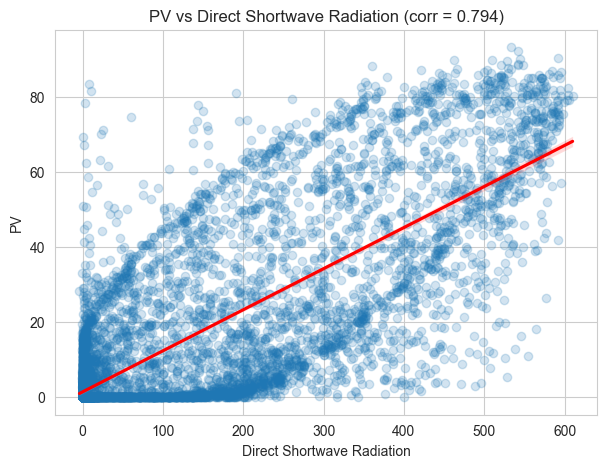

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["Direct Shortwave Radiation"]
y = df["PV"]

corr = x.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"PV vs Direct Shortwave Radiation (corr = {corr:.3f})")
plt.xlabel("Direct Shortwave Radiation")
plt.ylabel("PV")
plt.show()


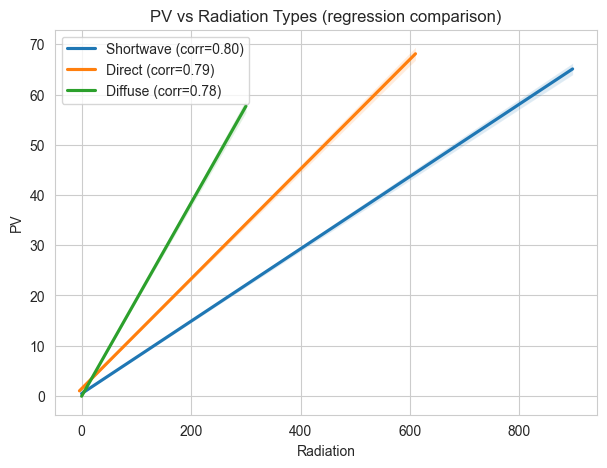

In [19]:
plt.figure(figsize=(7,5))

sns.regplot(
    x=df["Shortwave Radiation"],
    y=df["PV"],
    scatter=False,
    label=f"Shortwave (corr={df['Shortwave Radiation'].corr(df['PV']):.2f})"
)

sns.regplot(
    x=df["Direct Shortwave Radiation"],
    y=df["PV"],
    scatter=False,
    label=f"Direct (corr={df['Direct Shortwave Radiation'].corr(df['PV']):.2f})"
)

sns.regplot(
    x=df["Diffuse Shortwave Radiation"],
    y=df["PV"],
    scatter=False,
    label=f"Diffuse (corr={df['Diffuse Shortwave Radiation'].corr(df['PV']):.2f})"
)

plt.legend()
plt.title("PV vs Radiation Types (regression comparison)")
plt.xlabel("Radiation")
plt.ylabel("PV")
plt.show()


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# make sure datetime index
df = df.copy()
df.index = pd.to_datetime(df.index)

# useful time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month


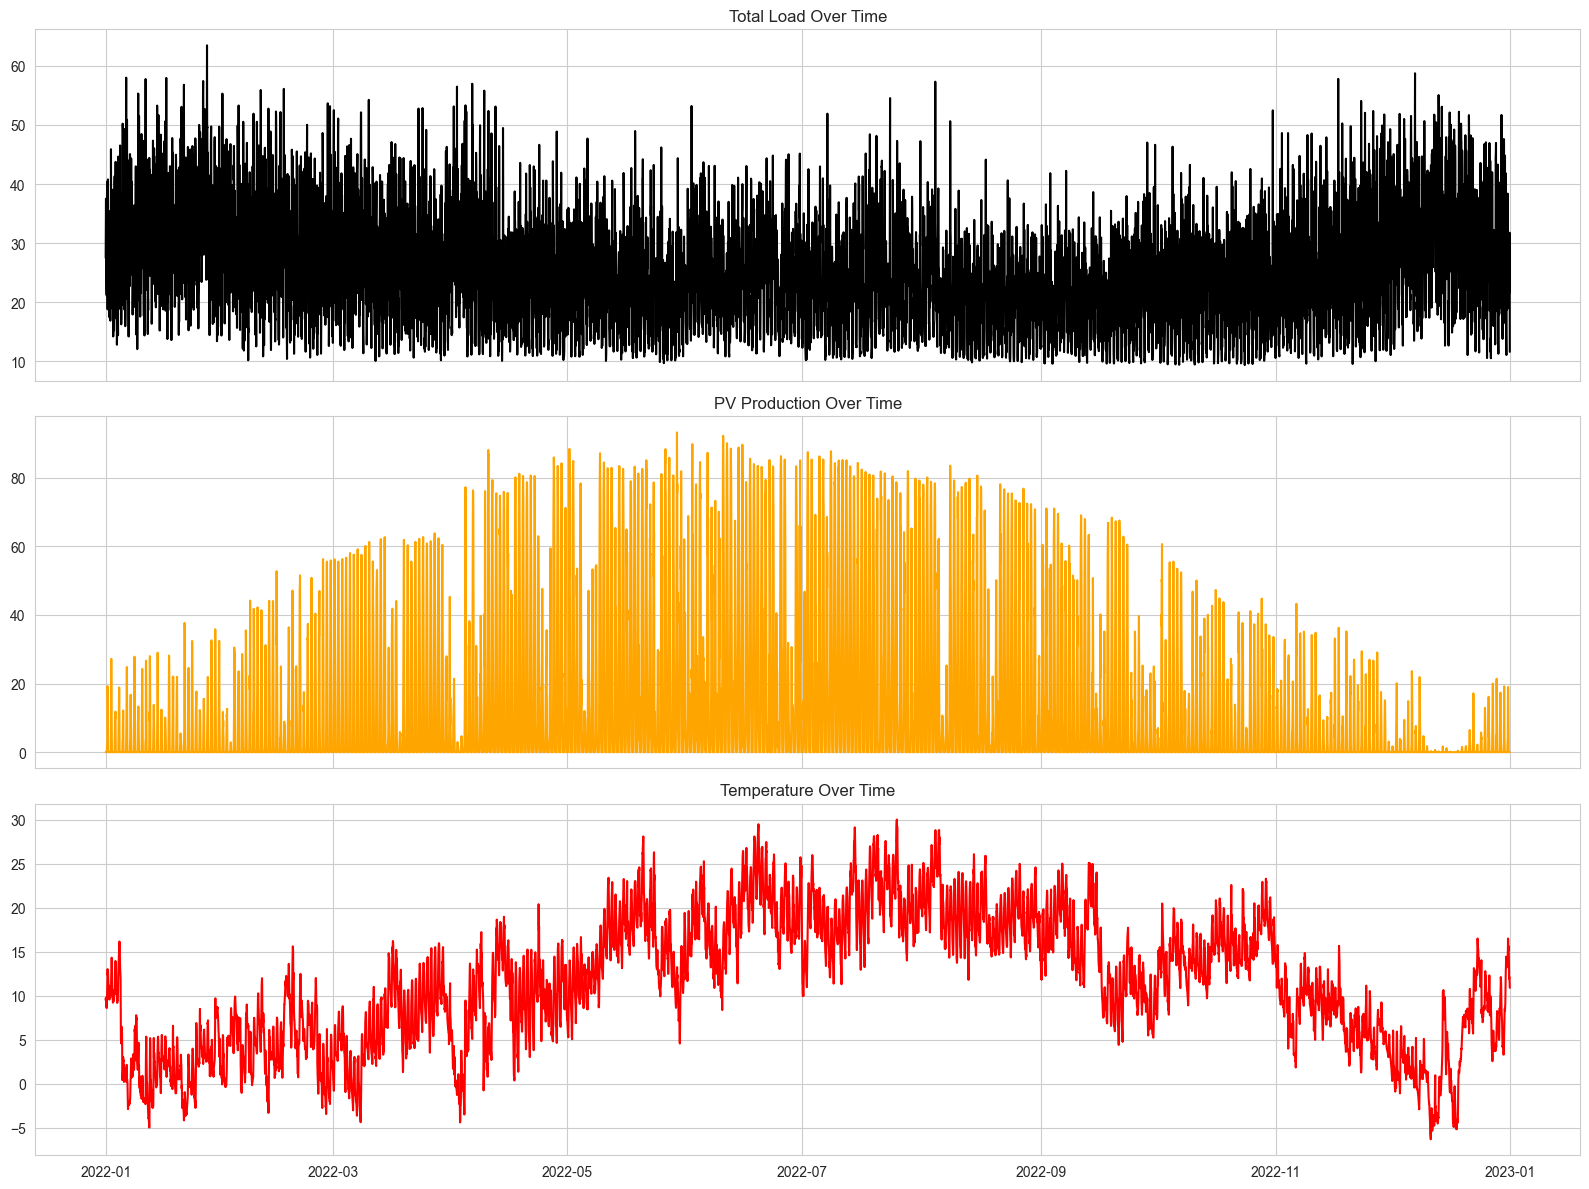

In [21]:
fig, ax = plt.subplots(3,1, figsize=(16,12), sharex=True)

# total load
ax[0].plot(df.index, df["Sum"], color="black")
ax[0].set_title("Total Load Over Time")

# PV
ax[1].plot(df.index, df["PV"], color="orange")
ax[1].set_title("PV Production Over Time")

# temperature
ax[2].plot(df.index, df["Temperature"], color="red")
ax[2].set_title("Temperature Over Time")

plt.tight_layout()
plt.show()


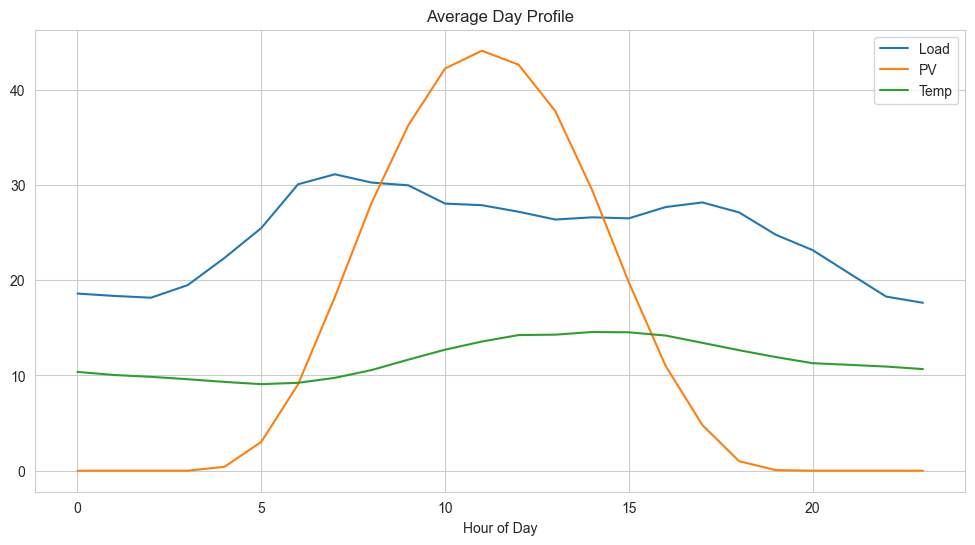

In [22]:
hourly = df.groupby("hour").mean(numeric_only=True)

plt.figure(figsize=(12,6))
plt.plot(hourly.index, hourly["Sum"], label="Load")
plt.plot(hourly.index, hourly["PV"], label="PV")
plt.plot(hourly.index, hourly["Temperature"], label="Temp")
plt.title("Average Day Profile")
plt.xlabel("Hour of Day")
plt.legend()
plt.show()


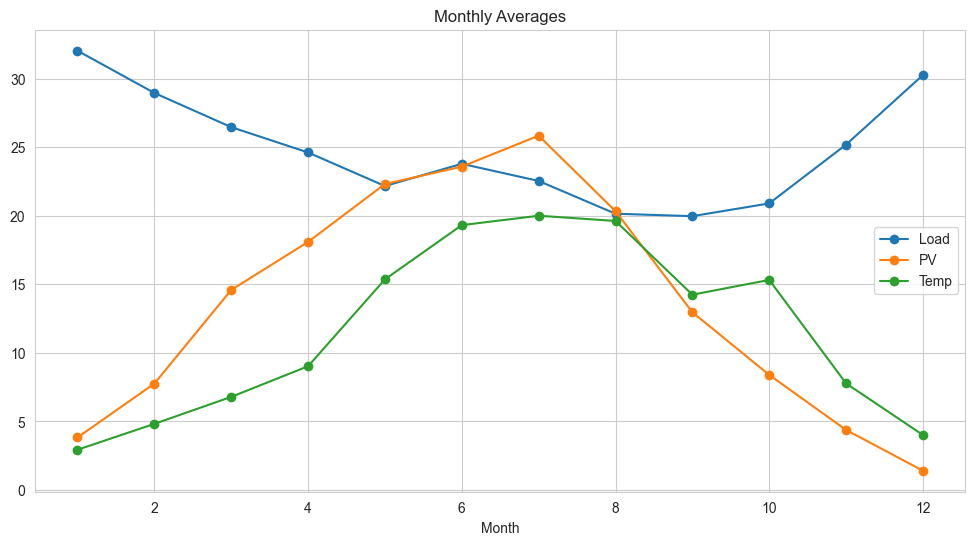

In [23]:
monthly = df.groupby("month").mean(numeric_only=True)

plt.figure(figsize=(12,6))
plt.plot(monthly.index, monthly["Sum"], marker="o", label="Load")
plt.plot(monthly.index, monthly["PV"], marker="o", label="PV")
plt.plot(monthly.index, monthly["Temperature"], marker="o", label="Temp")
plt.title("Monthly Averages")
plt.xlabel("Month")
plt.legend()
plt.show()


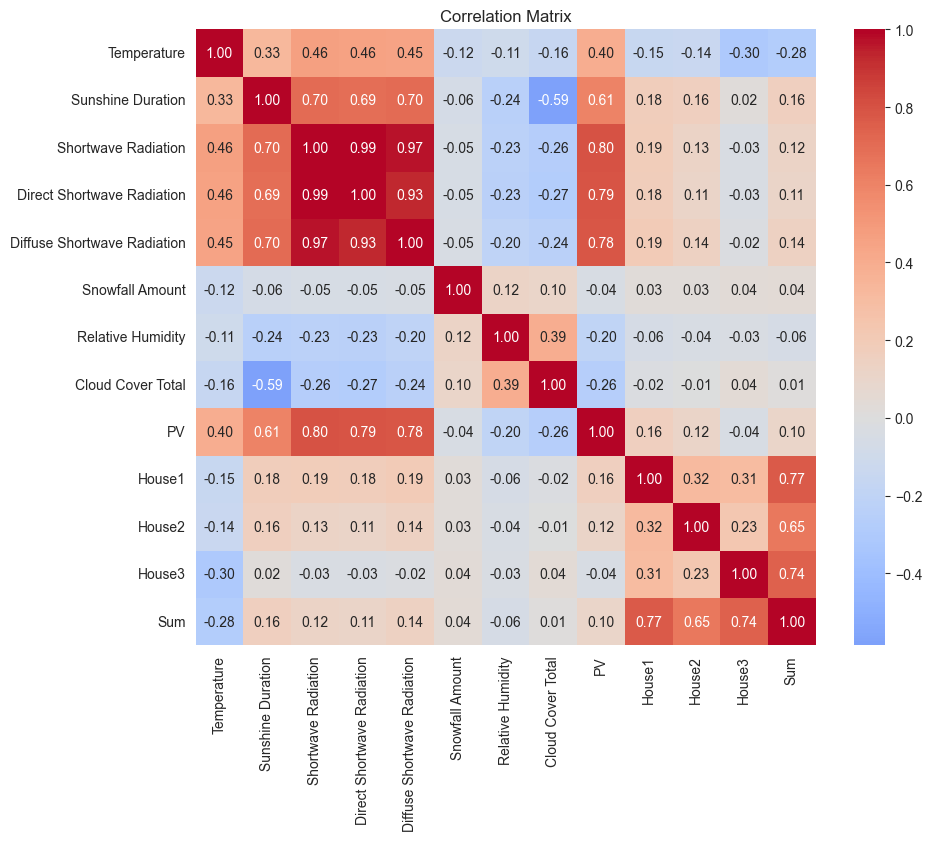

In [25]:
plt.figure(figsize=(10,8))
corr = df.drop(columns=["hour","dayofweek","month"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png", dpi=600, bbox_inches="tight")
plt.show()
